In [1]:
# Calculating  correlation, covariance between FMCG stocks and Nifty50 index

In [2]:

import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns


In [3]:

ticker = ['HINDUNILVR.NS', 'NESTLEIND.NS','COLPAL.BO','^NSEI']

raw_data = yf.download(ticker,start='2021-01-01',interval='5d')
df = pd.DataFrame(raw_data)['Close']
df.rename(columns = {'HINDUNILVR.NS' : 'Hindustan Unilever','COLPAL.BO' : 'Colgate', 'NESTLEIND.NS':'Nestle India', '^NSEI':'Nifty50' },inplace=True) 


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


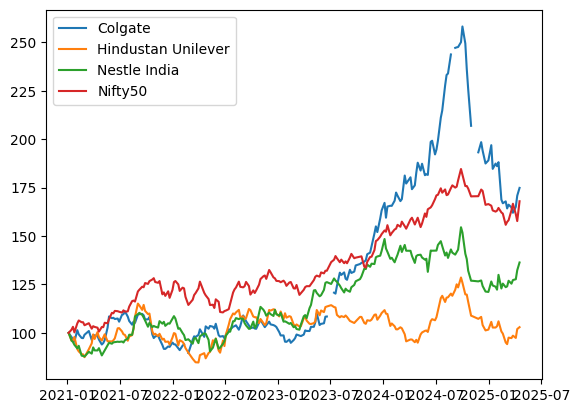

In [4]:
plt.plot(df/df.iloc[0]*100) # return from 2021
plt.legend(df)
plt.show()


In [5]:
# returns generated - natural log terms
log_return = np.log(df/df.shift(1))
log_return.dropna(inplace = True)
print(log_return)

Ticker       Colgate  Hindustan Unilever  Nestle India   Nifty50
Date                                                            
2021-01-15 -0.021861           -0.041408     -0.039808  0.016359
2021-01-20 -0.012390            0.002039     -0.008599  0.014513
2021-01-25 -0.011759            0.018358     -0.015161 -0.028101
2021-02-04  0.059871           -0.066329     -0.019789  0.045092
2021-02-09 -0.021620           -0.013156      0.014244  0.014241
...              ...                 ...           ...       ...
2025-03-20 -0.008482           -0.002383     -0.012014  0.032000
2025-03-25 -0.016994            0.012806      0.014878  0.020402
2025-04-04  0.018750           -0.011847      0.003232 -0.032820
2025-04-09  0.034346            0.045910      0.035906 -0.022308
2025-04-17  0.023182            0.009529      0.029726  0.062830

[206 rows x 4 columns]


In [6]:
# average returns in since 2021 (annualized)
log_mean = log_return.mean()*252*100
print(log_mean)


Ticker
Colgate               67.890433
Hindustan Unilever     9.548656
Nestle India          41.409883
Nifty50               66.823695
dtype: float64


In [7]:
# calculate standard deviations
std_dev = log_return.std()*252**0.5 
print(std_dev)


Ticker
Colgate               0.438205
Hindustan Unilever    0.426346
Nestle India          0.387295
Nifty50               0.298334
dtype: float64


In [8]:
# calculate covariance (annualized)
covariance = log_return.cov()*252
print(covariance)


Ticker               Colgate  Hindustan Unilever  Nestle India   Nifty50
Ticker                                                                  
Colgate             0.192024            0.055814      0.064552  0.035510
Hindustan Unilever  0.055814            0.181771      0.084649  0.032907
Nestle India        0.064552            0.084649      0.149997  0.032502
Nifty50             0.035510            0.032907      0.032502  0.089003


In [9]:
# calculate correlation between them
correlation = log_return.corr()
print(correlation)


Ticker               Colgate  Hindustan Unilever  Nestle India   Nifty50
Ticker                                                                  
Colgate             1.000000            0.298746      0.380356  0.271624
Hindustan Unilever  0.298746            1.000000      0.512648  0.258713
Nestle India        0.380356            0.512648      1.000000  0.281296
Nifty50             0.271624            0.258713      0.281296  1.000000


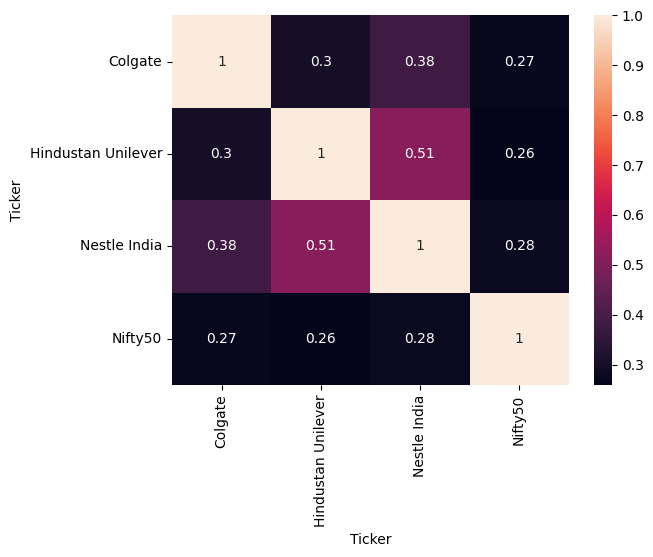

In [10]:
# heatmap depiction
sns.heatmap(correlation, annot=True)
plt.show()

In [11]:
# what will be the risk in portfolio with 2 asset ( Nestle and Nifty50)?
# weight assigned to each asset is 0.5 (equal weight)

In [12]:
# portfolio variance

# formula = ((Weight of Asset 1)^2 * Variance of Asset 1 + (Weight of Asset 2)^2 * Variance of Asset 2 + 2 * Weight of Asset 1 * Weight of Asset 2 * Covariance between Asset 1 and Asset 2.)
weight = np.array([0.5]*2)

portfolio_variance = np.dot(weight,np.dot(covariance.loc[['Nestle India','Nifty50'],['Nestle India','Nifty50']],weight.T))
print(round(portfolio_variance,3))

0.076


In [13]:
# portfolio standard deviation
portfolio_std_dev = round(portfolio_variance**0.5,3)
print(portfolio_std_dev)


0.276
